In [1]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



#Визуализируйте распределение значений признаков Survived, Pclass, Age, Sex. Parch - 2 балла


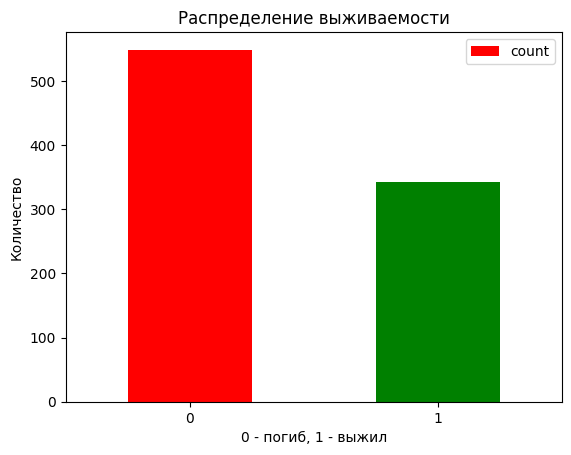

In [104]:
#Survived
df['Survived'].value_counts().plot(
    kind='bar',
    title='Распределение выживаемости',
    xlabel='0 - погиб, 1 - выжил',
    ylabel='Количество',
    rot=0,
    color=['red', 'green'],
    legend=True

);


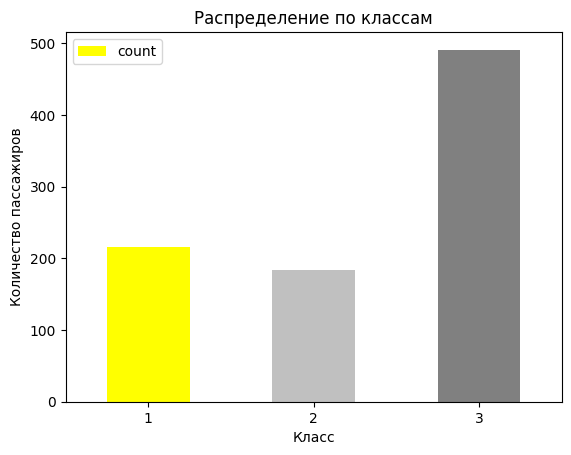

In [119]:
# Pclass
df['Pclass'].value_counts().sort_index().plot(
    kind='bar',
    title='Распределение по классам',
    xlabel='Класс',
    ylabel='Количество пассажиров',
    rot=0,
    color=['yellow', 'silver', 'grey'],
    legend=True

)
plt.show()

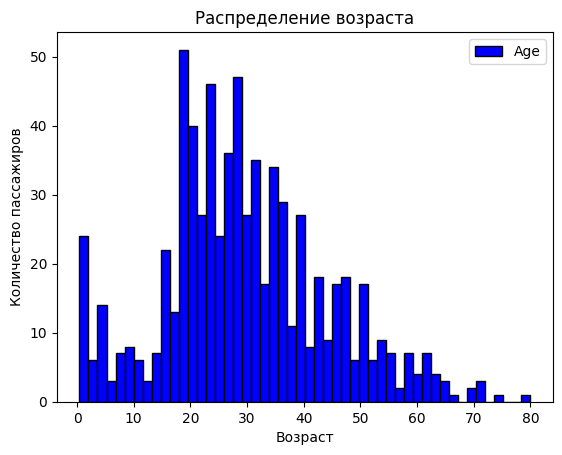

In [106]:
#Age
df['Age'].plot(
    kind='hist',
    title='Распределение возраста',
    xlabel='Возраст',
    ylabel='Количество пассажиров',
    bins=50,
    color='blue',
    edgecolor='black',
    legend=True
);

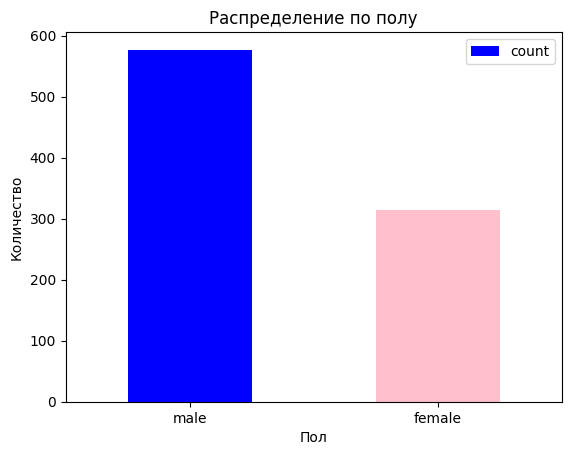

In [107]:
#Sex
df['Sex'].value_counts().plot(
    kind='bar',
    title='Распределение по полу',
    xlabel='Пол',
    ylabel='Количество',
    rot=0,
    color=['blue', 'pink'],
    legend=True
);


In [31]:
df['Parch'].max()

6

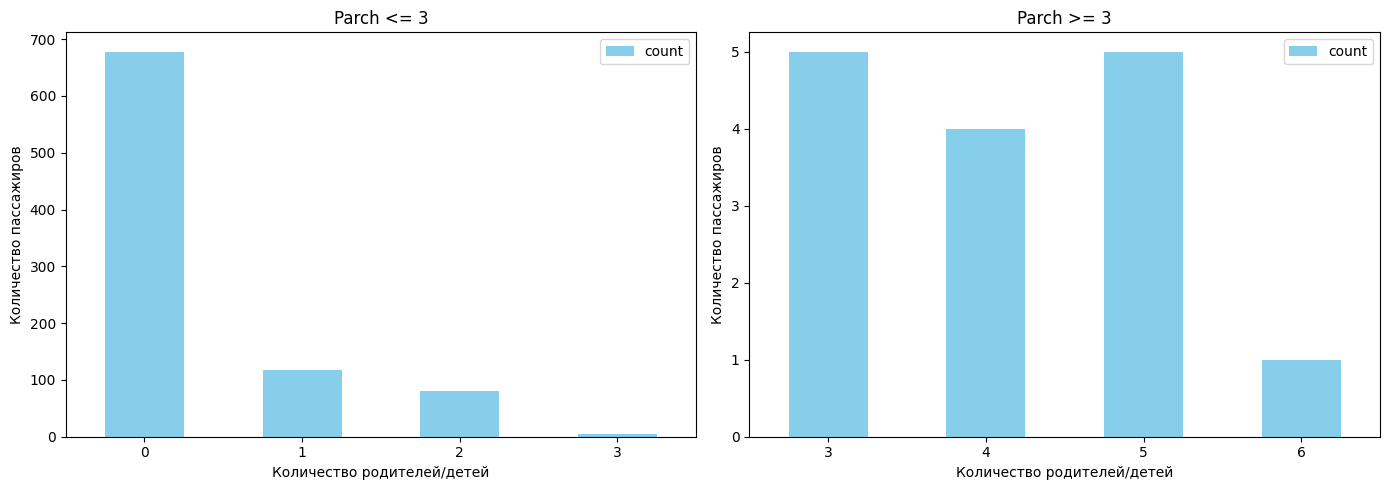

In [109]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Parch'] <= 3]['Parch'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    title='Parch <= 3',
    xlabel='Количество родителей/детей',
    ylabel='Количество пассажиров',
    rot=0,
    color='skyblue',
    legend=True
)

df[df['Parch'] >= 3]['Parch'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[1],
    title='Parch >= 3',
    xlabel='Количество родителей/детей',
    ylabel='Количество пассажиров',
    rot=0,
    color='skyblue',
    legend=True
)

plt.tight_layout()
plt.show()

Постройте график типа boxplot для столбца Age - 1 балл


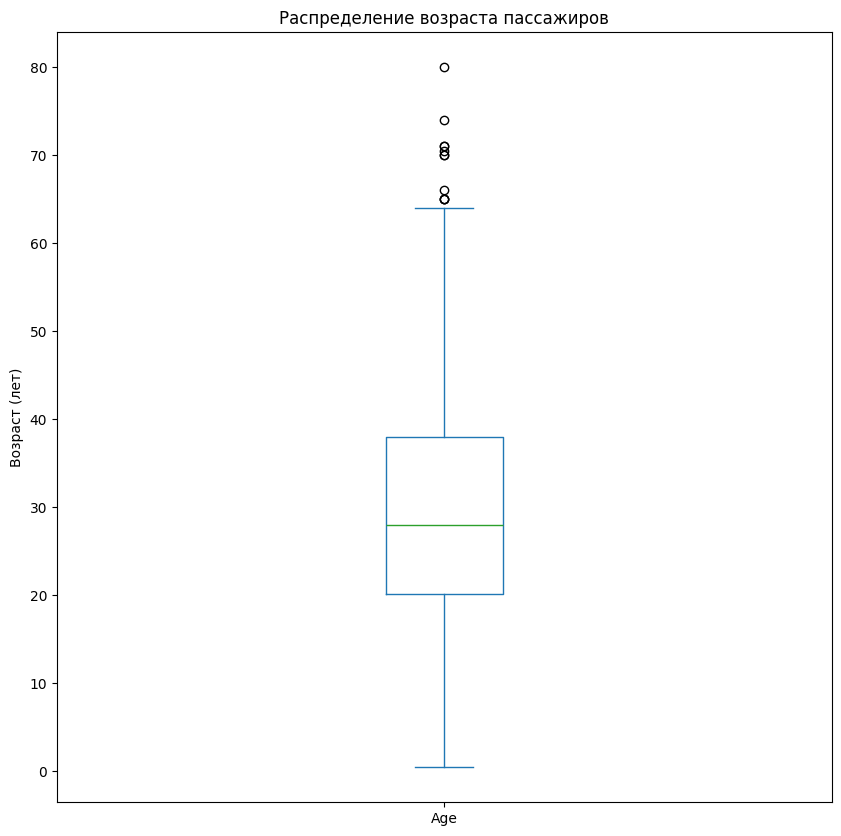

In [110]:

fig, axes = plt.subplots(1, figsize=(10, 10))  # правильный размер (ширина, высота)
# Age
df['Age'].plot(
    kind='box',
    title='Распределение возраста пассажиров',
    ylabel='Возраст (лет)',
    ax=axes,
    legend=True
)
plt.show()

На представленном boxplot видно распределение возраста пассажиров Титаника:

- Нижняя граница (минимум): 0 лет
- Верхняя граница (максимум): 65 лет .Верхняя граница = Q3 + 1.5 * IQR


- Межквартильный размах (ящик): от 20 до 37 лет
- Медиана (зеленая линия): 27 лет
- Выбросы: присутствуют пассажиры старше 70 лет

Это означает, что 50% всех пассажиров находились в возрасте от 20 до 37 лет, при этом средний возраст пассажира составлял примерно 27 лет. На корабле были пожилые люди старше 70 лет, которые отмечены как выбросы. Все значения до 65 лет считаются "нормальными" (не выбросами)



Постройте график типа pie chart для переменных Survived, Pclass, подпишите доли в процентах - 1 балл


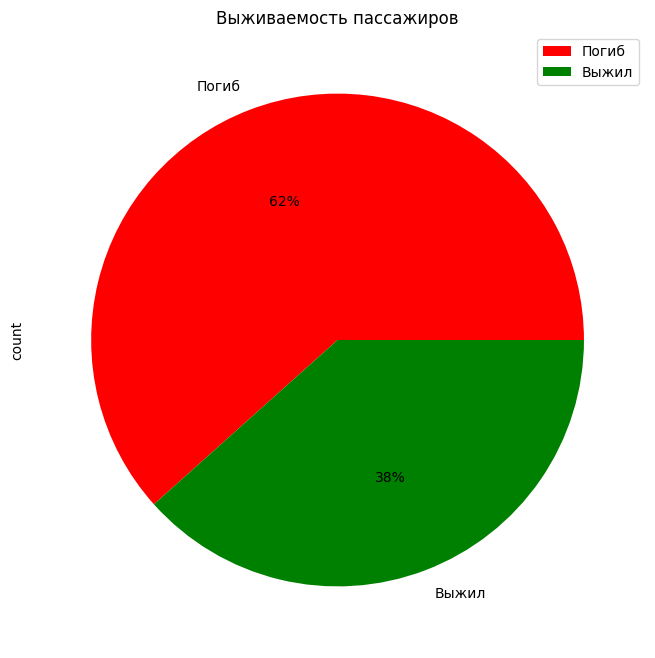

In [111]:

# Survived pie chart
df['Survived'].value_counts().plot(
    kind='pie',
    title='Выживаемость пассажиров',
    labels=['Погиб', 'Выжил'],
    autopct='%1.0f%%',
    colors=['red', 'green'],
    figsize=(8, 8),
    legend=True
);

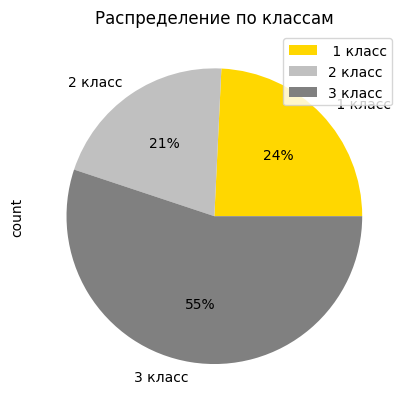

In [113]:
# Pclass pie chart
df['Pclass'].value_counts().sort_index().plot(
    kind='pie',
    title='Распределение по классам',
    labels=[' 1 класс', '2 класс', '3 класс'],
    autopct='%1.0f%%',
    colors=['gold', 'silver', 'grey'],
    legend=True
);

Постройте график типа pairplot для всех числовых переменных датасета - 1 балл


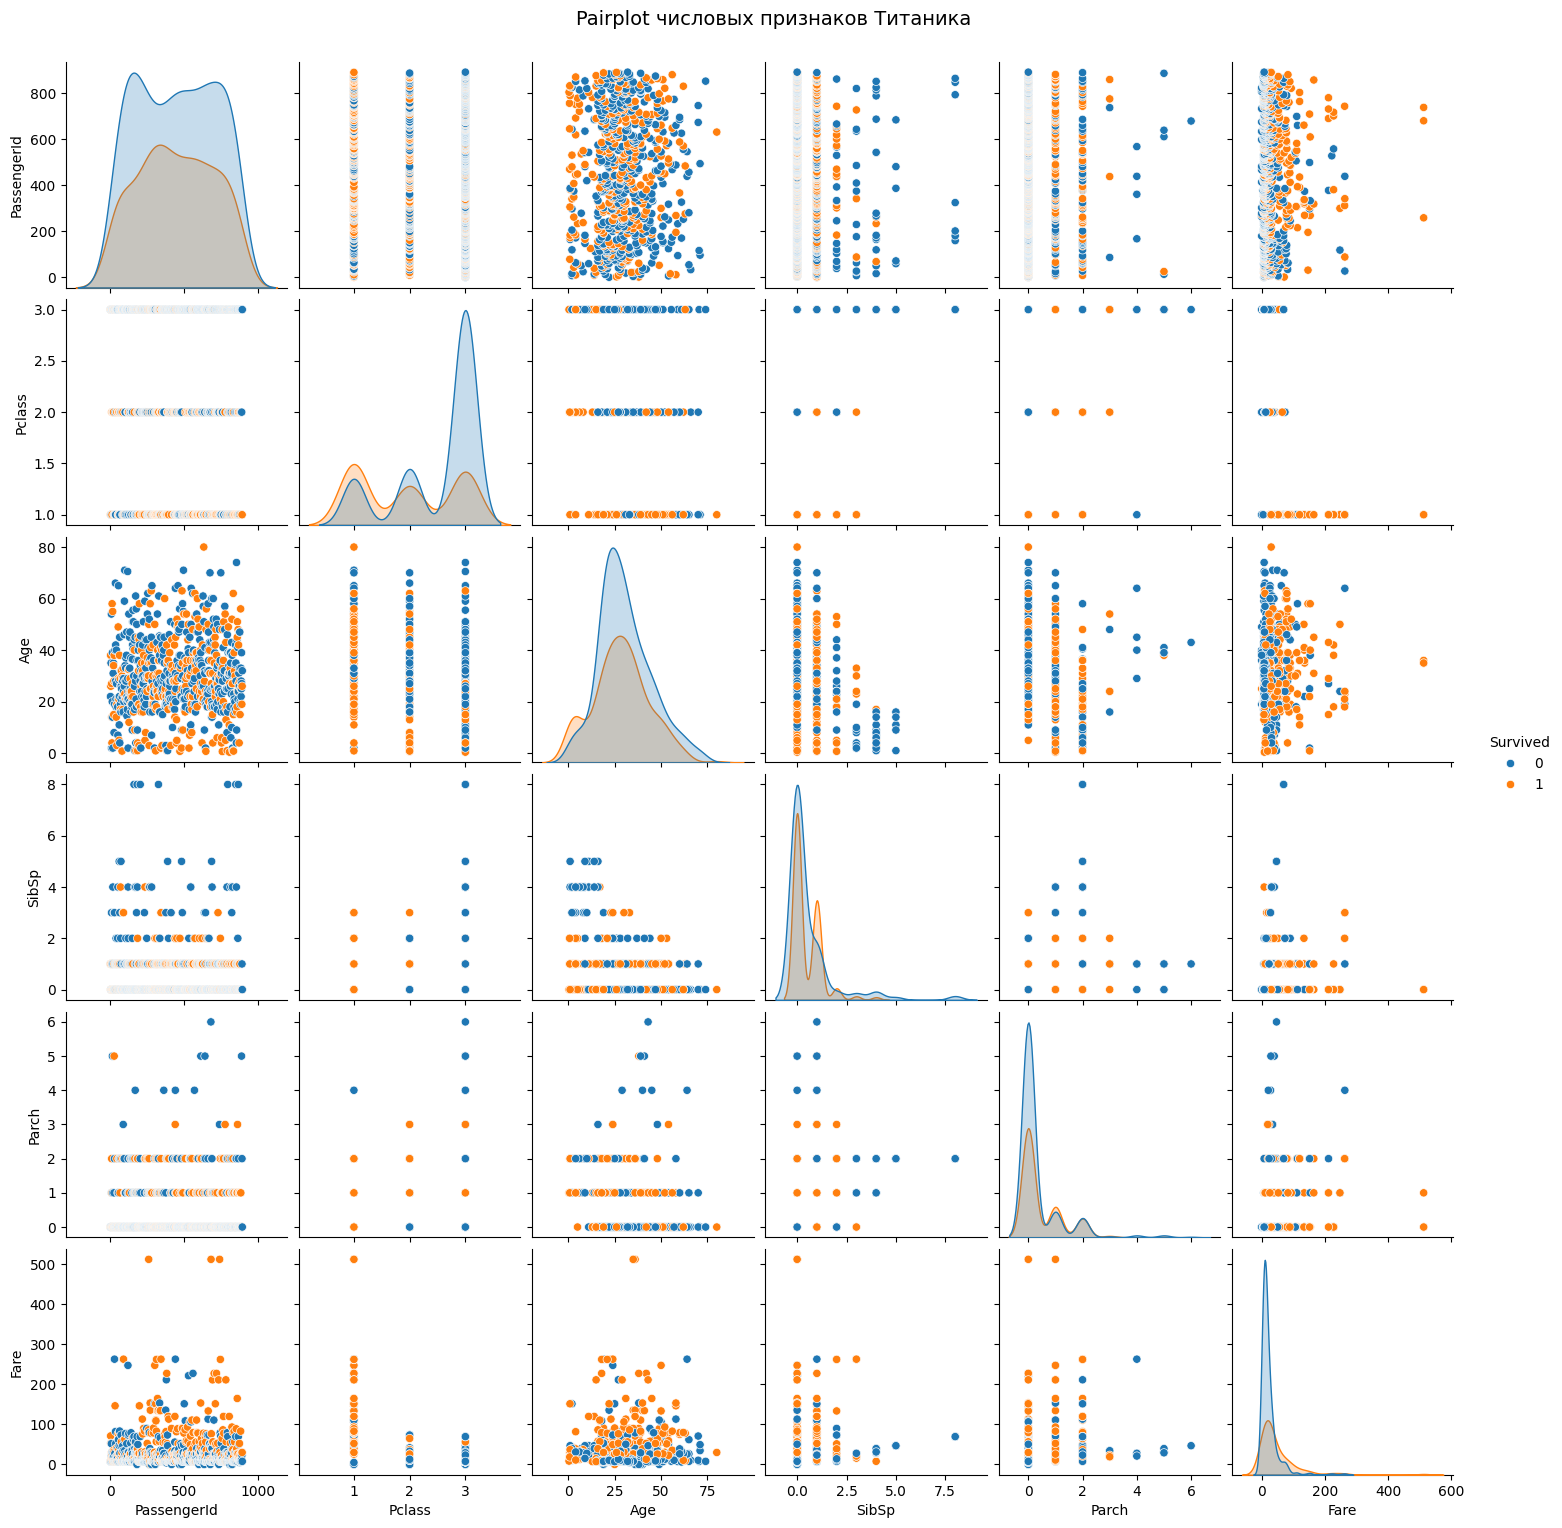

In [90]:
import seaborn as sns
# Числовые переменные
numeric_cols = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Строим pairplot
sns.pairplot(df, hue='Survived')
plt.suptitle('Pairplot числовых признаков Титаника', y=1.02, fontsize=14)
plt.show()

Постройте интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе - 2 балла


In [118]:

data = dict(
    categories=['Всего', '1 класс','2 класс','3 класс',
                '1 класс мужчины','1 класс женщины',
                '2 класс мужчины','2 класс женщины',
                '3 класс мужчины','3 класс женщины'],
    parent=['','Всего','Всего','Всего',
            '1 класс','1 класс',
            '2 класс','2 класс',
            '3 класс','3 класс'],
    value=[len(df),
           len(df[df['Pclass']==1]), len(df[df['Pclass']==2]), len(df[df['Pclass']==3]),
           len(df[(df['Pclass']==1)&(df['Sex']=='male')]), len(df[(df['Pclass']==1)&(df['Sex']=='female')]),
           len(df[(df['Pclass']==2)&(df['Sex']=='male')]), len(df[(df['Pclass']==2)&(df['Sex']=='female')]),
           len(df[(df['Pclass']==3)&(df['Sex']=='male')]), len(df[(df['Pclass']==3)&(df['Sex']=='female')])]
)

fig = px.sunburst(data, names='categories', parents='parent', values='value', branchvalues='total')
fig.show()